## PARTE 1: EXTRACCIÓN DE CARACTERÍSTICAS
Vamos a analizar varias stats de intensidad globales, luego sacaremos algunas stats de la matriz de GLCM (global), también stats de los filtros de gradiente, y también stats del histograma (no se si del oriented gradients u otro). Además, ya que tenemos la máscara, sacaremos algunos datos de la máscara también, como área de la lesión relativa, perímetro, circularidad, algo así (aunque si usamos las imágenes de mamas sanas, que no tienen máscara, no meteremos estas features)

Luego clasificcaremos usando quizá random forest y evaluaremos la importancia de cada variable, quizá descartando las que menos.
Por último, posiblemente metamos una red neuronal que 'mejore' las features para la clasificación, a ver si mejora, y así justificamos que el trabajo sea híbrido con deep learning.

SOBRE EL USO DE MÁSCARAS:
Si usamos features obtenidas de las máscaras, luego cada vez que queramos clasificar una imagen nueva, esa imagen debe venir con máscara. Además, al usar la feature de la máscara conviene meter las fotos completas, no los ROI. Si el investigador no tiene máscara (lo más probable) tendríamos que confiar en nuestro algoritmo segmentador para usarlo de máscara, pero no es muy fiable, al menos para micros no es nada fiable. Por tanto, es mejor EN MI OPINION usar el algoritmo segmentador para seleccionar la zona a clasificar, pero que en ultima instancia elija el profesional.

En ese punto tenemos dos opciones: usar el algoritmo segmentador solo sobre esa zona sospechosa, donde posiblemente funcione mejor, y usarlo como máscara para crear features de máscara. Otra opción es NO usar features de máscara, y clasificar solo con las ROI. Ahora bien, eso puede dar una clasificación bastante mala. Habrá que comprobarlo. Vamos a clasificar SOLO CON LAS ROI de momento, porque es más realista. Si conseguimos un algoritmo de segmentación robusto, al menos TRAS SELECCIONAR UNA ZONA, podríamos probar usando también features de la máscara.

In [1]:
import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from skimage.measure import regionprops
from skimage.feature import local_binary_pattern

def extract_features(img, mask=None):
    """
    Extrae features globales de una mamografía:
    - Intensidad global
    - Histograma de intensidades (32 bins)
    - Textura GLCM
    - Gradientes globales
    - Morfología (si hay máscara)
    """

    # Asegurar escala de grises y tipo uint8
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.uint8)

    feats = []

    # -----------------------------
    # 1. INTENSIDAD GLOBAL
    # -----------------------------
    vals = img[img > 0].reshape(-1) #Esto elimina los píxeles negros del fondo, para que no estropeen
    #las features

    img[img == 0] = vals.mean()
    #Aquí sustituimos los píxeles negros de img por píxeles que sean la media del resto

    feats.append(vals.mean())
    feats.append(vals.std())
    feats.append(skew(vals))
    feats.append(kurtosis(vals))
    p10, p50, p90 = np.percentile(vals, [10, 50, 90])
    feats.extend([p10, p50, p90])

    # -----------------------------
    # 2. HISTOGRAMA (32 bins)
    # -----------------------------
    hist, _ = np.histogram(vals, bins=32, range=(0, 255), density=True)
    feats.extend(hist.tolist())

    # -----------------------------
    # 3. TEXTURA GLCM GLOBAL
    # -----------------------------
    # Redimensionar para que GLCM no sea enorme
    img_small = cv2.resize(img, (256, 256))

    glcm = graycomatrix(img_small,
                        distances=[1],
                        angles=[0],
                        levels=256,
                        symmetric=True,
                        normed=True)

    feats.append(graycoprops(glcm, 'contrast')[0, 0])
    feats.append(graycoprops(glcm, 'homogeneity')[0, 0])
    feats.append(graycoprops(glcm, 'energy')[0, 0])
    feats.append(graycoprops(glcm, 'correlation')[0, 0])

    # -----------------------------
    # 4. GRADIENTES GLOBALES
    # -----------------------------
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    Gmag = np.sqrt(Gx**2 + Gy**2)
    Lap = cv2.Laplacian(img, cv2.CV_64F)

    feats.append(Gmag.mean())
    feats.append(Gmag.std())
    feats.append(Lap.mean())
    feats.append(Lap.std())

    # -------------------------------
    # 5. --- LBP (Local Binary Patterns) ---
    #------------------------------------

    # ...
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    
    # P+2 = 10 patrones → 10 bins
    lbp_hist, _ = np.histogram(lbp.ravel(),
                               bins=10,
                               range=(0, 10),
                               density=True)
    
    feats.extend(lbp_hist.tolist())

    # -----------------------------
    # 5. MORFOLOGÍA (si hay máscara)
    # -----------------------------
    if mask is not None:
        mask_bin = (mask > 0).astype(np.uint8)

        props = regionprops(mask_bin.astype(int))
        if len(props) > 0:
            r = props[0]

            area = r.area
            perimeter = r.perimeter if r.perimeter > 0 else 1
            circularity = 4 * np.pi * area / (perimeter**2)
            eccentricity = r.eccentricity
            solidity = r.solidity

            feats.extend([area, perimeter, circularity, eccentricity, solidity])
        else:
            feats.extend([0, 0, 0, 0, 0])

    return np.array(feats, dtype=float)

In [2]:
#Creamos un array con los nombres de las features:
feature_names = []

# 1. Intensidad global
feature_names += ["mean", "std", "skew", "kurtosis", "p10", "p50", "p90"]

# 2. Histograma (32 bins)
feature_names += [f"hist_bin_{i}" for i in range(32)]

# 3. GLCM
feature_names += ["glcm_contrast", "glcm_homogeneity", "glcm_energy", "glcm_correlation"]

# 4. Gradientes
feature_names += ["grad_mag_mean", "grad_mag_std", "lap_mean", "lap_std"]

# 5. LBP (59 bins)
feature_names += [f"lbp_uniform_{i}" for i in range(10)]

#Faltan cuatro de la máscara. Añadirlos si se usa máscara

Descripción:
- mean y var son la media de las intensidades de la foto, var la desviación estándar
- Los percentiles te dicen los umbrales de intensidad: p10 te dice la intensidad tal que el 10% inferior de los píxeles tiene menos intensidad. El p50 (mediana) te dice la intensidad tal que el 50% de los pixeles la tienen menor y el otro 50 mayor.
- skew mide si la distribución está inclinada hacia intensidades bajas o altas, o sea, si hicieramos un histograma de intensidades, mide si hay cola pa la izq o pa la der o es muy simétrica la dist.
- kurtosis: mide lo picuda que es la distribycion, o sea, el histograma de intensidades.
- El HISTOGRAMA básicamente coge el histograma, partido en 32 subintervalos, de intensidad, y coge comof eatures el número de píxeles en cada subintervalo
- Textura GLCM: Calcula la matriz GLCM, sobre una imagen más pequeña, redimensionada (porque si no sale enorme) y a partir de la matriz saca cuatro datos, contraste, homogeneidad, energía y correlación
- Hace un filtro de gradientes, que devuelve una imagen como la original, y de cada uno calcula la media y la varianza. También el laplaciano
- De la máscara, si la hay, coge el área (numero de pixeles blancos), el perímetro, la circularidad, la eccentricidad y la solidez (solidity)

## Algoritmos de clasificación
## Primero, un algoritmo que clasifique entre MASS y calcifications
Lo primero será extraer las características y guardarlas en una matriz X

### Creación de características:

In [3]:
#FUNCION PREPROCESADO ROIs
#Las ROIs no van a cambiarse de resolución, van a ir tal cual están. Solo aplicaremos algunas cosas como CLAHE
def preprocess_ML_ROI(img):
    # 1) Percentile clipping
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)

    # 2) Normalización 0–1
    img = (img - p1) / (p99 - p1)

    # 3) Convertir a 8 bits
    img = (img * 255).astype(np.uint8)

    # 4) CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    return img

In [4]:
#Creamos la matriz X. Cada fila deberá corresponder a una imagen. Cogeremos solo las que sean mass
#o calcification
import os
from PIL import Image
import matplotlib.pyplot as plt
import cv2

carpeta_origen = 'Imagenes ROI INbreast RENOMBRADAS CON MARGEN'
carpeta_binarias = 'Imagenes mascaras segmentacion INbreast RENOMBRADAS'
files = os.listdir(carpeta_origen)

#COGEMOS SOLO LOS DE MASS O MICRO. Para mass, cogemos mass y mass_micro, ya que el ROI solo coge la masa
files = [x for x in files if x.startswith(("MASS",'MICRO'))]

#Aplicamos la función y guardamos el resultado
X = []
i = 1
for e in files:
    ruta_imagen = os.path.join(carpeta_origen, e)
    nombre_mascara = e.replace('_roi.png', '_mask.png')
    ruta_mascara = os.path.join(carpeta_binarias, nombre_mascara)

    #Importamos la foto
    im = Image.open(ruta_imagen)
    im = im.convert('L')
    im = np.array(im)
    #Preprocesamos la imagen
    im = preprocess_ML_ROI(im)
        
    #Aplicamos la función de creación de características
    feats = extract_features(im)
    X.append(feats)
    
    print(f'creadas features para imagen {e}')
    print(f'`{i}/{len(files)} fotos completadas', end = '\r')
    i = i+1

X = np.vstack(X) #Para convertirlo en matriz

#También debemos crear el array Y de características, con 1 o 0
Y = [0 if f.startswith("MASS") else 1 for f in files]
#Será 0 para MASS y 1 para MICRO

creadas features para imagen MASS_bi-rads_2_22580367_5eae9beae14d26fd_MG_L_CC_ANON_roi.png
creadas features para imagen MASS_bi-rads_2_22580419_5eae9beae14d26fd_MG_L_ML_ANON_roi.png
creadas features para imagen MASS_bi-rads_2_22670620_e15a16f87b4f9782_MG_R_CC_ANON_roi.png
creadas features para imagen MASS_bi-rads_2_22670673_e15a16f87b4f9782_MG_R_ML_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_20587758_81cd83d2f4d78528_MG_L_CC_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_20587810_81cd83d2f4d78528_MG_L_ML_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_20588308_493155e17143edef_MG_L_ML_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_20588334_493155e17143edef_MG_L_CC_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_20588680_036aff49b8ac84f0_MG_L_ML_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_22580192_5530d5782fc89dd7_MG_R_CC_ANON_roi.png
creadas features para imagen MASS_bi-rads_3_22580244_5530d5782fc89dd7_MG_R_ML_ANON_roi.png

### Ahora entrenamos un random forest para ver las importancias de cada feature, pero no es el que usaremos para clasificar

Top 20 features más importantes:
Feature 12: importancia = 0.0575
Feature 10: importancia = 0.0496
Feature 9: importancia = 0.0467
Feature 8: importancia = 0.0454
Feature 55: importancia = 0.0398
Feature 14: importancia = 0.0343
Feature 37: importancia = 0.0312
Feature 36: importancia = 0.0304
Feature 49: importancia = 0.0299
Feature 13: importancia = 0.0290
Feature 16: importancia = 0.0275
Feature 41: importancia = 0.0263
Feature 11: importancia = 0.0260
Feature 35: importancia = 0.0244
Feature 3: importancia = 0.0240
Feature 21: importancia = 0.0238
Feature 20: importancia = 0.0228
Feature 1: importancia = 0.0217
Feature 22: importancia = 0.0189
Feature 23: importancia = 0.0180


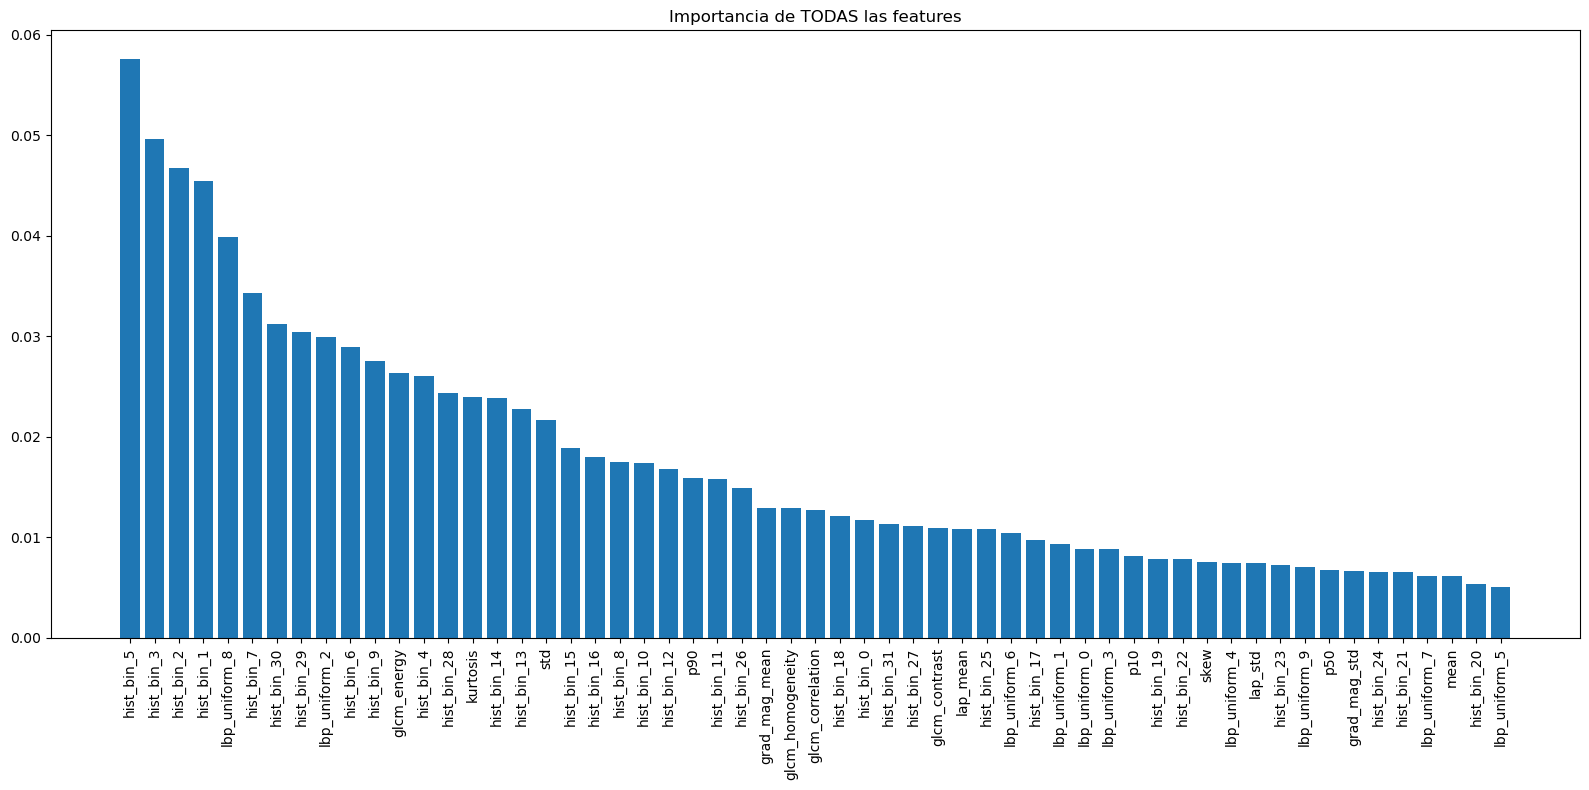

In [9]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Entrenamos un Random Forest muy ligero
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, Y)

# Importancias
importances = rf.feature_importances_

# Ordenar de mayor a menor
idx_sorted = np.argsort(importances)[::-1]

print("Top 20 features más importantes:")
for i in idx_sorted[:20]:
    print(f"Feature {i}: importancia = {importances[i]:.4f}")

#Ploteamos las importancias

plt.figure(figsize=(16, 8))
plt.bar([feature_names[i] for i in idx_sorted], importances[idx_sorted])
plt.xticks(rotation=90)
plt.title("Importancia de TODAS las features")
plt.tight_layout()
plt.show()

### Entrenamiento del modelo, usando SVN:

In [5]:
#Separamos primero entre datos de test y datos de train
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

# X = matriz de features (n_samples, n_features)
# Y = etiquetas (0 = MICRO, 1 = MASS)

# 1) Pipeline: escalado + SVM RBF
#El SVM necesita valores escalados, entre cero y uno (creo) para todas las features. Por eso antes escalamos.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

# 2) SVM tiene dos hiperparámetros. Vamos a hacer grid search para buscar los mejores
param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100, 300, 1000],
    "svm__gamma": ["scale", "auto",1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001]}

# 3) Validación cruzada
clf = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

clf.fit(X, Y)

print("Mejores hiperparámetros:", clf.best_params_)
print("Mejor accuracy CV:", clf.best_score_)

Mejores hiperparámetros: {'svm__C': 10, 'svm__gamma': 0.003}
Mejor accuracy CV: 0.8597014925373134


In [6]:
from sklearn.model_selection import train_test_split
#Con los mejores hiperparámetros, entrenamos el modelo. Separamos entre datos de test y de train
#Mejores hiperparámetros:
svm_C = 1
svm_gamma = 0.1

# 1) Split train/test
#Vamos a hacerlo de forma que en los datos de test haya más o menos el mismo número de cada uno.
# Para ello vamos a quitar algunos de la clase que más haya del test

# Split normal estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    stratify=Y,
    random_state=42
)

# Convertir a arrays por si acaso
X_test = np.array(X_test)
y_test = np.array(y_test)

# Separar clases en test
X_mass  = X_test[y_test == 0]
X_micro = X_test[y_test == 1]

# Queremos igualar el número
n = min(len(X_mass), len(X_micro))

# Submuestrear
idx_mass  = np.random.choice(len(X_mass),  n, replace=False)
idx_micro = np.random.choice(len(X_micro), n, replace=False)

X_test_bal = np.vstack([X_mass[idx_mass], X_micro[idx_micro]])

# Aquí viene la clave: NO indexamos y_mass ni y_micro
y_test_bal = np.hstack([
    np.zeros(n, dtype=int),   # MASS
    np.ones(n, dtype=int)     # MICRO
])

# Mezclar
idx = np.random.permutation(len(X_test_bal))
X_test = X_test_bal[idx]
y_test = y_test_bal[idx]

In [7]:
print(y_test)
print(y_train)

[0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 1 1 0 0 1 0
 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Validación del modelo:

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2) Modelo final con los mejores hiperparámetros
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma=0.003, class_weight="balanced", probability=True))
])

# 3) Entrenar
best_model.fit(X_train, y_train)

# 4) Evaluar en test
y_pred = best_model.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy en test: 0.9090909090909091

Matriz de confusión:
 [[31  2]
 [ 4 29]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.94      0.88      0.91        33

    accuracy                           0.91        66
   macro avg       0.91      0.91      0.91        66
weighted avg       0.91      0.91      0.91        66



In [10]:
#Calculamos la ROC_auc también

from sklearn.metrics import roc_curve, auc

# 1) Obtener los scores continuos del modelo
#    Para SVM con probability=True → predict_proba
#    Para SVM sin probability=True → decision_function

scores = best_model.predict_proba(X_test)[:, 1]   # probabilidad de clase 1 (MICRO)

# 2) Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, scores)

# 3) Calcular el AUC
roc_auc = auc(fpr, tpr)

print("AUC-ROC:", roc_auc)

AUC-ROC: 0.9522497704315886


In [47]:
#Valores SHAP: calculo
import shap
carpeta_origen = 'Imagenes ROI INbreast RENOMBRADAS CON MARGEN'
carpeta_binarias = 'Imagenes mascaras segmentacion INbreast RENOMBRADAS'
files = os.listdir(carpeta_origen)
files = [x for x in files if x.startswith(("MASS",'MICRO'))]
ruta_imagen = os.path.join(carpeta_origen, files[50])
im = Image.open(ruta_imagen)
im = im.convert('L')
im = np.array(im)
    #Preprocesamos la imagen
im = preprocess_ML_ROI(im)
    #Aplicamos la función de creación de características
feats = extract_features(im)


# Convertir X_train a matriz numérica REAL
X_train_np = np.vstack(X_train)

# Crear background correctamente
background = shap.kmeans(X_train_np, 10)

# Crear el explainer
explainer = shap.KernelExplainer(best_model.predict, background)

# Calcular SHAP para la imagen actual
shap_values = explainer.shap_values(feats.reshape(1, -1))



C:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

In [48]:
print("SHAPE:", background.shape)
print("DTYPE:", background.dtype)
print("FIRST ELEMENT TYPE:", type(background[0]))

AttributeError: 'DenseData' object has no attribute 'shape'

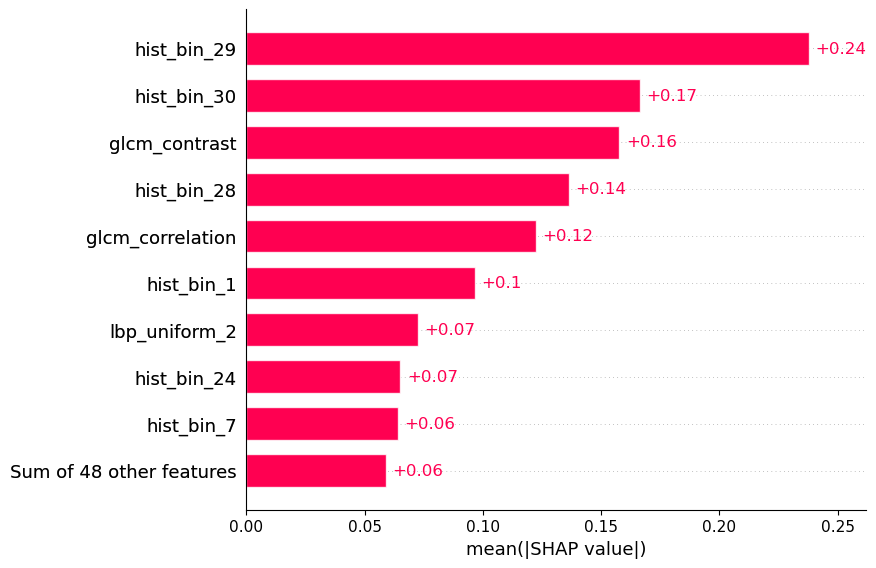

In [43]:
base_values = np.array([explainer.expected_value])

# 3. data debe ser 2D: (1, n_features)
data = feats.reshape(1, -1)                                    # (1, n_features)

# 4. Crear Explanation correctamente
exp = shap.Explanation(
    values = shap_values,
    base_values = base_values,
    data = data,
    feature_names = feature_names
)

# 5. Ahora sí: bar plot funciona
shap.plots.bar(exp)

In [14]:
import joblib
joblib.dump(best_model, "modelo_MASSvsCALC.pkl")

['modelo_MASSvsCALC.pkl']

In [40]:
import os

print("Ruta absoluta:", os.path.abspath("background_massvscalc.npy"))
print("Tamaño del archivo:", os.path.getsize("background_massvscalc.npy"))

Ruta absoluta: C:\Users\pedro\Documents\MÁSTER UNIR 💻\TFM\extracción de imágenes del dataset\background_massvscalc.npy
Tamaño del archivo: 7613


## Clasificación de bi-rads: una para MASS y otra para MICRO
### Clasificación con MASS
Probaremos de nuevo solo con SVM.

In [50]:
## PASO 1: EXTRACCIÓN DE CARACTERÍSTICAS ----#
#Creamos la matriz X. Cada fila deberá corresponder a una imagen. Cogeremos solo las que sean mass
#o calcification
import os
from PIL import Image
import matplotlib.pyplot as plt
import cv2

carpeta_origen = 'Imagenes ROI INbreast RENOMBRADAS CON MARGEN'
carpeta_binarias = 'Imagenes mascaras segmentacion INbreast RENOMBRADAS'
files = os.listdir(carpeta_origen)

#COGEMOS SOLO LOS DE MASS
files = [x for x in files if x.startswith("MASS")]

#Aplicamos la función y guardamos el resultado
X = []
i = 1
for e in files:
    ruta_imagen = os.path.join(carpeta_origen, e)
    nombre_mascara = e.replace('_roi.png', '_mask.png')
    ruta_mascara = os.path.join(carpeta_binarias, nombre_mascara)

    #Importamos la foto
    im = Image.open(ruta_imagen)
    im = im.convert('L')
    im = np.array(im)
    #Preprocesamos la imagen
    im = preprocess_ML_ROI(im)
        
    #Aplicamos la función de creación de características
    feats = extract_features(im)
    X.append(feats)
    
    print(f'creadas features para imagen {e}; {i}/{len(files)} fotos completadas', end = '\r')
    i = i+1

X = np.vstack(X) #Para convertirlo en matriz


creadas features para imagen MASS_MICRO_bi-rads_6_22670147_e1f51192f7bf3f5f_MG_R_ML_ANON_roi.png; 108/108 fotos completadasmpletadas

In [51]:
## PASO 2: CREAR EL Y DE CLASES
import re

def extraer_birads(nombre):
    # Busca patrones tipo bi-rads_3 o bi-rads_4c y devuelve el número
    match = re.search(r'bi-rads[_\-]?(\d+)', nombre.lower())
    if match:
        return int(match.group(1))
    else:
        return None  # por si algún archivo no tiene birads

y = [extraer_birads(nombre) for nombre in files]
y = np.array(y)
print(y)

#REDUCIMOS EL NÚMERO DE CLASES PARA MEJORAR EL MODELO.
#Vamos a considerar 1,2,3 como benigno (bajo riesgo) y 4,5,6 como sospechoso/maligno (alto riesgo)

y_fusion = np.copy(y)

# bajo riesgo
y_fusion[np.isin(y_fusion, [1, 2, 3])] = 0

# alto riesgo
y_fusion[np.isin(y_fusion, [4, 5, 6])] = 1

print(y_fusion)

[2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 5 6 6 5 5 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 3 3 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [52]:
#PASO 3: SEPARAR ENTRE TEST Y TRAIN----------------
from sklearn.model_selection import train_test_split

# 1) Split train/test
#Vamos a hacerlo de forma que en los datos de test haya más o menos el mismo número de cada uno.
# Para ello vamos a quitar algunos de la clase que más haya del test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)

print(y_test)
print(y_train)

#El stratify se asegura de q haya la misma proporción de cada clase en train y test

[1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1]
[0 1 1 1 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 0
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1
 0 1 1 1 0 1 1 0 0 1 0 1]


In [53]:
np.save('background_clasifmass.npy',X_train)

In [18]:
#PASO 4: ENTRENAR EL MODELO DE SVM
#Primero, probamos cuáles son los mejores hiperparámetros
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

# X = matriz de features (n_samples, n_features)
# Y = etiquetas (0 = MICRO, 1 = MASS)

# 1) Pipeline: escalado + SVM RBF
#El SVM necesita valores escalados, entre cero y uno (creo) para todas las features (creo).
#Por eso antes escalamos.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

# 2) SVM tiene dos hiperparámetros. Vamos a hacer grid search para buscar los mejores
param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100, 300, 1000],
    "svm__gamma": ["scale", "auto",1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001]}

# 3) Validación cruzada
clf = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

clf.fit(X_train, y_train)

print("Mejores hiperparámetros:", clf.best_params_)
print("Mejor accuracy CV:", clf.best_score_)

Mejores hiperparámetros: {'svm__C': 10, 'svm__gamma': 'scale'}
Mejor accuracy CV: 0.7326797385620915


In [21]:
#Ahora hacemos el modelo y validamos
C_best = 10
gamma_best = 'scale'

# 2) Modelo final con los mejores hiperparámetros
best_model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C = C_best, gamma = gamma_best, class_weight="balanced", probability=True))
])

# 3) Entrenar
best_model2.fit(X_train, y_train)

# 4) Evaluar en test
y_pred = best_model2.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy en test: 0.7272727272727273

Matriz de confusión:
 [[7 1]
 [5 9]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.58      0.88      0.70         8
           1       0.90      0.64      0.75        14

    accuracy                           0.73        22
   macro avg       0.74      0.76      0.72        22
weighted avg       0.78      0.73      0.73        22



In [22]:
import joblib
joblib.dump(best_model2, "modelo_birads_mass.pkl")

['modelo_birads_mass.pkl']